# Práctica 4. Clasificación supervisada con datos de una encuesta sobre COVID

**Asignatura:** Informática Aplicada / Aprendizaje Computacional  
**Tipo de práctica:** Aprendizaje automático supervisado para clasificación  
**Fichero de trabajo:** `DatosEncuestaCOVID_limpio_XX.xlsx`

En esta práctica vas a resolver **una tarea central de clasificación binaria** usando algoritmos clásicos de `scikit-learn`.

## Objetivo principal
Predecir la variable:

- `sospecha_covid_bin = 1` si la persona sospecha haber pasado la COVID,
- `sospecha_covid_bin = 0` si no lo sospecha.

## Algoritmos que se compararán

- **Regresión logística**
- **Árbol de decisión**
- **Bosque aleatorio**

Además, se usará un clasificador de **línea base** para tener una referencia mínima.


## Cómo leer este cuaderno

Para que no haya dudas, en este notebook aparecen siempre etiquetas muy claras:

### **Debes completar**
Tienes que escribir o modificar código.

### **Debes ejecutar**
Solo tienes que ejecutar la celda y observar el resultado.

### **Debes ejecutar y revisar**
Debes ejecutar el bloque, comprobar que tiene sentido con tus datos y modificarlo si lo crees necesario.

### **Debes interpretar**
Debes escribir una respuesta breve explicando qué significa el resultado.

## Muy importante
En esta práctica **no basta con que el código funcione**. También debes:

- entender qué variables usas,
- justificar las decisiones de recodificación,
- comparar modelos,
- interpretar figuras y métricas,
- redactar conclusiones prudentes.


## Qué debes entregar

1. Este notebook **completado y ejecutado en orden**.
2. Las respuestas escritas en las secciones marcadas como **Debes interpretar**.
3. Las figuras generadas correctamente.
4. Unas conclusiones finales en lenguaje claro.


## Paquetes y recordatorios útiles

Si fuese necesario, los paquetes podrían instalarse antes de empezar. En JupyterLab Desktop para Windows suele ser más robusto usar el Python exacto del kernel.

```python
# Debes ejecutar esta celda solo si faltan paquetes
import sys, subprocess
python_exe = sys.executable
if python_exe.startswith("\\?\"):
    python_exe = python_exe[4:]
subprocess.run([python_exe, "-m", "pip", "install", "pandas", "numpy", "matplotlib", "scikit-learn", "openpyxl"], check=True)
print("Instalación completada. Reinicia el kernel antes de continuar.")
```


In [29]:
# Debes ejecutar este bloque

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)


# 1. Carga del fichero y primera inspección

## Qué debes hacer en esta sección

- **Debes completar** tu código de estudiante.
- **Debes ejecutar** la carga del Excel.
- **Debes revisar** que el fichero se ha leído correctamente.
- **Debes interpretar** de forma breve la estructura general del conjunto de datos.


In [30]:
# Debes completar esta parte

# Sustituye XX por tu código de estudiante, por ejemplo "07" o "23"
codigo = "40"

ruta = f"DatosEncuestaCOVID_limpio_{codigo}.xlsx"
df = pd.read_excel(ruta)

print("Fichero cargado correctamente:", ruta)
print("Dimensiones del DataFrame:", df.shape)


Fichero cargado correctamente: DatosEncuestaCOVID_limpio_40.xlsx
Dimensiones del DataFrame: (116, 47)


In [31]:
# Debes ejecutar este bloque

print("Número de columnas:", len(df.columns))
print("Primeras 35 columnas:")
print(df.columns.tolist()[:35])

print("Primeras filas:")
display(df.head())


Número de columnas: 47
Primeras 35 columnas:
['cp_antes_clean', 'sexo_clean', 'edad_clean', 'talla_clean', 'domicilio_antes_clean', 'profesion_antes_clean', 'ocio_clean', 'extranjero_clean', 'cp_durante_clean', 'domicilio_durante_clean', 'convivientes_durante_clean', 'mascotas_clean', 'seguridad_mes_1_clean', 'fumador_clean', 'alcohol_clean', 'antidepresivos_clean', 'tranquilizantes_clean', 'tratamiento_dolor_clean', 'estado_salud_clean', 'enf_riesgo_1_clean', 'enf_riesgo_2_clean', 'salud_trimestre_clean', 'hospital_ingreso_clean', 'hospital_pruebas_clean', 'patologia_consis_clean', 'patologia_sinasis_clean', 'covid_contacto_clean', 'covid_sospecha_clean', 'covid_pcr_clean', 'covid_anticuerpos_clean', 'transporte_clean', 'seguridad_frecuencia_clean', 'bebidas_clean', 'suplementos_clean', 'n_enf_metabolica']
Primeras filas:


,cp_antes_clean,sexo_clean,edad_clean,talla_clean,domicilio_antes_clean,profesion_antes_clean,ocio_clean,extranjero_clean,cp_durante_clean,domicilio_durante_clean,...,tiene_comorbilidad,total_sintomas,tiene_sintomas,total_vacunas,tiene_vacuna,peso_clean,imc,edad_grupo,imc_categoria,sintomas_grupo
0,8,1,42,167,2,7,1,0,8,3,...,1,3,1,1,1,72,25,1,1,1
1,19,0,56,167,2,0,0,0,18,2,...,1,0,0,2,1,65,23,2,1,0
2,20,0,33,167,2,6,1,0,19,2,...,1,9,1,0,0,88,31,1,3,3
3,23,0,65,167,2,7,1,0,22,2,...,1,2,1,0,0,58,20,3,1,1
4,23,0,63,167,2,2,1,0,22,2,...,1,1,1,1,1,59,21,3,1,1


In [32]:
# Debes ejecutar este bloque

display(df.describe(include="all").T.head(20))


,count,mean,std,min,25%,50%,75%,max
cp_antes_clean,116.0,17.181034,6.725163,0.0,14.75,20.0,20.0,29.0
sexo_clean,116.0,0.422414,0.496087,0.0,0.00,0.0,1.0,1.0
edad_clean,116.0,46.146552,13.448940,25.0,35.50,44.5,56.0,81.0
talla_clean,116.0,170.215517,1.864105,167.0,169.00,170.0,172.0,173.0
domicilio_antes_clean,116.0,1.965517,0.631507,0.0,2.00,2.0,2.0,3.0
profesion_antes_clean,116.0,4.767241,3.048471,0.0,2.00,5.0,7.0,10.0
ocio_clean,116.0,0.793103,0.740355,0.0,0.00,1.0,1.0,3.0
extranjero_clean,116.0,0.129310,0.336999,0.0,0.00,0.0,0.0,1.0
cp_durante_clean,116.0,16.474138,6.304534,0.0,14.00,19.0,19.0,28.0
domicilio_durante_clean,116.0,1.844828,0.764466,0.0,1.00,2.0,2.0,3.0


## Debes interpretar

Escribe un comentario breve sobre:

- cuántas filas y columnas tiene tu fichero,
- si predominan variables numéricas, categóricas o binarias,
- y si ves ya posibles valores ausentes o categorías textuales.


> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

116 filas y 47 columnas. La mayoria de las variables son binarias (0 o 1) y pocas son numéricas y categóricas. Variables como alcohol y fumador tienen todos el mismo valor, por lo que no aportan información.

# 2. Variables útiles para clasificación

En esta práctica vamos a construir un conjunto de variables relativamente sencillo. Como este mismo fichero ya se ha trabajado en una práctica anterior, aquí **no se pide una inspección larga**, sino una **revisión breve orientada a clasificación**.

Nos centraremos en variables relacionadas con:

- sexo,
- edad,
- IMC,
- tabaquismo,
- alcohol,
- antidepresivos,
- tranquilizantes,
- enfermedades metabólicas,
- enfermedades respiratorias,
- riesgo/EPOC,
- número de síntomas,
- contacto COVID,
- sospecha de COVID.


In [33]:
# Debes ejecutar este bloque

variables_inspeccion = [
    "sexo_clean", "fumador_clean", "alcohol_clean", "antidepresivos_clean",
    "tranquilizantes_clean", "covid_contacto_clean", "covid_sospecha_clean",
    "estado_salud_clean"
]

for col in variables_inspeccion:
    if col in df.columns:
        print("" + "=" * 80)
        print(col)
        print(df[col].value_counts(dropna=False).head(12))


sexo_clean
sexo_clean
0    67
1    49
Name: count, dtype: int64
fumador_clean
fumador_clean
0    116
Name: count, dtype: int64
alcohol_clean
alcohol_clean
0    116
Name: count, dtype: int64
antidepresivos_clean
antidepresivos_clean
0    113
1      3
Name: count, dtype: int64
tranquilizantes_clean
tranquilizantes_clean
0    108
1      8
Name: count, dtype: int64
covid_contacto_clean
covid_contacto_clean
0    109
1      7
Name: count, dtype: int64
covid_sospecha_clean
covid_sospecha_clean
0    99
1    17
Name: count, dtype: int64
estado_salud_clean
estado_salud_clean
1    78
2    25
0    13
Name: count, dtype: int64


## Debes interpretar

Indica solo de forma breve:

- qué variables parecen fáciles de recodificar,
- cuáles presentan categorías ambiguas o respuestas libres,
- y por qué `49.COVID-SOSPECHA_1` puede ser una variable objetivo razonable para clasificación binaria.


> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

No hace falta recodificar ninguna variable porque ya lo hicimos en la práctica anterior. Variables como alcohol y fumador no no se deberían usar. El objetivo es saber si un usuario tiene covid o indicios de covid, por lo que la variable de covid_sospecha es una buena elección para ser la variable objetivo.

# 3. Construcción de una tabla de trabajo para clasificación

Ahora vamos a crear un `DataFrame` nuevo llamado `trabajo`, con variables ya adaptadas al modelado.

## Qué debes hacer en esta sección

- **Debes ejecutar** las funciones auxiliares.
- **Debes ejecutar y revisar** la recodificación propuesta.
- **Debes modificar la recodificación si lo consideras necesario**.
- **Debes interpretar** qué variables nuevas has creado.


In [34]:
# Debes ejecutar este bloque

trabajo = pd.DataFrame(index=df.index)

def texto_normalizado(serie):
    return serie.astype("string").str.lower().str.strip()

def contiene(serie, patron):
    return texto_normalizado(serie).str.contains(patron, regex=True, na=False)

def bin_si_no(serie):
    s = texto_normalizado(serie)
    out = pd.Series(np.nan, index=serie.index, dtype="float")
    out.loc[s.isin(["si", "sí"])] = 1
    out.loc[s.eq("no")] = 0
    return out

def bin_no_vs_resto(serie):
    s = texto_normalizado(serie)
    out = pd.Series(np.nan, index=serie.index, dtype="float")
    out.loc[s.notna()] = 1
    out.loc[s.eq("no")] = 0
    return out

def contar_respuestas_si(dataframe, columnas):
    bloque = dataframe[columnas].astype("string").apply(lambda s: s.str.strip().str.lower())
    return bloque.eq("si").sum(axis=1)


In [35]:
# Debes ejecutar y revisar este bloque

# Sexo
trabajo["sexo"] = (
    df["sexo_clean"]
    .astype("string")
    .str.replace(":", "", regex=False)
    .str.strip()
)

# Edad, peso y talla
trabajo["edad"] = pd.to_numeric(df["edad_clean"], errors="coerce")
trabajo["peso_kg"] = pd.to_numeric(df["peso_clean"], errors="coerce")
trabajo["talla_m"] = pd.to_numeric(df["talla_clean"], errors="coerce")
trabajo["imc"] = df["imc"]

# Variables binarias de hábitos y medicación
trabajo["fumador_bin"] = df["fumador_clean"]
trabajo["alcohol_bin"] = df["alcohol_clean"]
trabajo["antidepresivos_bin"] = df["antidepresivos_clean"]
trabajo["tranquilizantes_bin"] = df["tranquilizantes_clean"]

# Enfermedades metabólicas y respiratorias
trabajo["enf_metabolicas_n"] = df["n_enf_metabolica"]
trabajo["enf_respiratorias_n"] = df["n_enf_respiratoria"]

# Riesgo / EPOC
s_epoc_1 = texto_normalizado(df["enf_riesgo_1_clean"])
s_epoc_2 = texto_normalizado(df["enf_riesgo_2_clean"]).fillna("")
trabajo["epoc_riesgo_bin"] = np.where(
    s_epoc_1.isin(["1"]) | (~s_epoc_2.isin(["0"])),
    1, 0
)

# Síntomas
trabajo["sintomas_n"] = df["total_sintomas"]

# Contacto COVID y variable objetivo
trabajo["contacto_covid_bin"] = df["covid_contacto_clean"]
trabajo["sospecha_covid_bin"] = df["covid_sospecha_clean"]

display(trabajo.head())


,sexo,edad,peso_kg,talla_m,imc,fumador_bin,alcohol_bin,antidepresivos_bin,tranquilizantes_bin,enf_metabolicas_n,enf_respiratorias_n,epoc_riesgo_bin,sintomas_n,contacto_covid_bin,sospecha_covid_bin
0,1,42,72,167,25,0,0,0,0,1,1,0,3,0,0
1,0,56,65,167,23,0,0,0,0,2,2,0,0,0,0
2,0,33,88,167,31,0,0,0,0,1,3,0,9,0,0
3,0,65,58,167,20,0,0,0,0,1,3,1,2,0,0
4,0,63,59,167,21,0,0,0,0,0,1,0,1,0,0


In [36]:
# Debes ejecutar y revisar este bloque

print("Valores perdidos por columna construida:")
display(trabajo.isna().sum().sort_values(ascending=False))

print("Distribución de la variable objetivo:")
display(trabajo["sospecha_covid_bin"].value_counts(dropna=False))


Valores perdidos por columna construida:


sexo                   0
edad                   0
peso_kg                0
talla_m                0
imc                    0
fumador_bin            0
alcohol_bin            0
antidepresivos_bin     0
tranquilizantes_bin    0
enf_metabolicas_n      0
enf_respiratorias_n    0
epoc_riesgo_bin        0
sintomas_n             0
contacto_covid_bin     0
sospecha_covid_bin     0
dtype: int64

Distribución de la variable objetivo:


sospecha_covid_bin
0    99
1    17
Name: count, dtype: int64

## Debes interpretar

Explica brevemente:

- qué variables nuevas has creado,
- cuáles son numéricas y cuáles categóricas/binarias,
- y si has decidido modificar alguna recodificación respecto a la propuesta inicial.


> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

Realmente no hemos creado ninguna variable, hemos usado las que ya tenemos en el dataset limpio. Variables numéricas tenemos por ejemplo el peso y el imc. Binarias el sexo. No he realizado ninguna recodificación.

# 4. Variable objetivo y figura inicial

Antes de entrenar modelos, conviene observar si la variable objetivo está equilibrada o no.


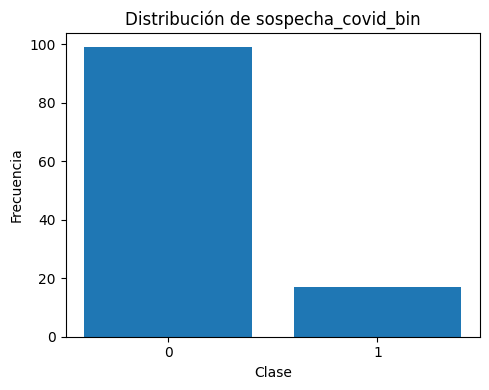

In [37]:
# Debes ejecutar este bloque

conteo_objetivo = trabajo["sospecha_covid_bin"].value_counts(dropna=True).sort_index()

plt.figure(figsize=(5, 4))
plt.bar(conteo_objetivo.index.astype(str), conteo_objetivo.values)
plt.title("Distribución de sospecha_covid_bin")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


## Debes interpretar

Comenta si la variable objetivo está equilibrada o desequilibrada. Explica por qué esto importa al evaluar clasificadores.


> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

Al ver que tenemos solo 99 personas que no tienen sospecha de covid y 17 que si, esta bastante desbalanceado. Esto afecta al modelo ya que puede aprender demás y decir que nadie tiene sospecha de covid. Si eso pasa tendríamos ya 99 aciertos y en el peor caso 17 fallos, teniendo un porcentaje de acierto de 99/116, un 85%. A pesar de ser una buena métrica, lo que nos interesa es que acierte para el otro grupo

# 5. Preparación del problema de clasificación

En esta versión reducida de la práctica usaremos una sola tarea supervisada:

- **clasificación binaria de `sospecha_covid_bin`**.

## Qué debes hacer en esta sección

- **Debes ejecutar y revisar** la selección de variables predictoras.
- **Debes ejecutar** la creación del conjunto final sin valores perdidos.
- **Debes ejecutar** la partición entrenamiento/prueba.


In [38]:
# Debes ejecutar y revisar este bloque

columnas_modelo = [
    "sexo",
    "edad",
    "imc",
    "fumador_bin",
    "alcohol_bin",
    "antidepresivos_bin",
    "tranquilizantes_bin",
    "enf_metabolicas_n",
    "enf_respiratorias_n",
    "epoc_riesgo_bin",
    "sintomas_n",
    "contacto_covid_bin"
]

objetivo = "sospecha_covid_bin"

display(columnas_modelo)


['sexo',
 'edad',
 'imc',
 'fumador_bin',
 'alcohol_bin',
 'antidepresivos_bin',
 'tranquilizantes_bin',
 'enf_metabolicas_n',
 'enf_respiratorias_n',
 'epoc_riesgo_bin',
 'sintomas_n',
 'contacto_covid_bin']

In [39]:
# Debes ejecutar este bloque

df_modelo = trabajo[columnas_modelo + [objetivo]].dropna().copy()

X = df_modelo[columnas_modelo]
y = df_modelo[objetivo].astype(int)

print("Dimensiones del conjunto final de modelado:", df_modelo.shape)
print("Distribución del objetivo en el conjunto final:")
print(y.value_counts())


Dimensiones del conjunto final de modelado: (116, 13)
Distribución del objetivo en el conjunto final:
sospecha_covid_bin
0    99
1    17
Name: count, dtype: int64


In [40]:
# Debes ejecutar este bloque

cat_cols = ["sexo"]
num_cols = [c for c in columnas_modelo if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)


Tamaño de entrenamiento: (87, 12)
Tamaño de prueba: (29, 12)


# 6. Entrenamiento de clasificadores clásicos

Vamos a comparar cuatro referencias:

- **Línea base**
- **Regresión logística**
- **Árbol de decisión**
- **Bosque aleatorio**

Las variables numéricas se escalarán y la variable categórica `sexo` se codificará automáticamente.


In [41]:
# Debes ejecutar este bloque

preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ],
    remainder="drop"
)

modelos = {
    "Línea base": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": LogisticRegression(max_iter=5000),
    "Árbol": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Bosque aleatorio": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        random_state=42
    )
}


In [42]:
# Debes ejecutar este bloque

resultados = []
modelos_ajustados = {}

for nombre, estimador in modelos.items():
    pipe = Pipeline([
        ("prep", preprocesador),
        ("clf", estimador)
    ])
    pipe.fit(X_train, y_train)
    modelos_ajustados[nombre] = pipe

    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None

    fila = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score) if y_score is not None else np.nan
    }
    resultados.append(fila)

tabla_resultados = pd.DataFrame(resultados).sort_values(
    by=["f1", "roc_auc", "accuracy"],
    ascending=False
)

display(tabla_resultados)


,modelo,accuracy,precision,recall,f1,roc_auc
1,Regresión logística,0.931034,0.75,0.75,0.750000,0.950
2,Árbol,0.896552,0.60,0.75,0.666667,0.835
3,Bosque aleatorio,0.827586,0.00,0.00,0.000000,0.840
0,Línea base,0.862069,0.00,0.00,0.000000,0.500


## Debes interpretar

Responde brevemente:

- ¿qué modelo obtiene la mejor `accuracy`?
- ¿qué modelo obtiene la mejor `f1`?
- ¿la línea base queda claramente por debajo o no?
- ¿por qué no basta con mirar solo la `accuracy`?


> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.


La regresión logística tiene el mayor accuracy con un 93%. También tiene el mayor f1 con un 75%. Vemos tambien que la línea base tiene muy malos resultados. Como dijimos anteriormente, al haber un gran desbalance, lo adecuado sería ver las demás métricas ya que ese accuracy puede ser alto por overfitting. Es útil ver el f1, ya que un bajo f1 nos indicaría que el accuracy si acierta bien las dos clases, no solo una.

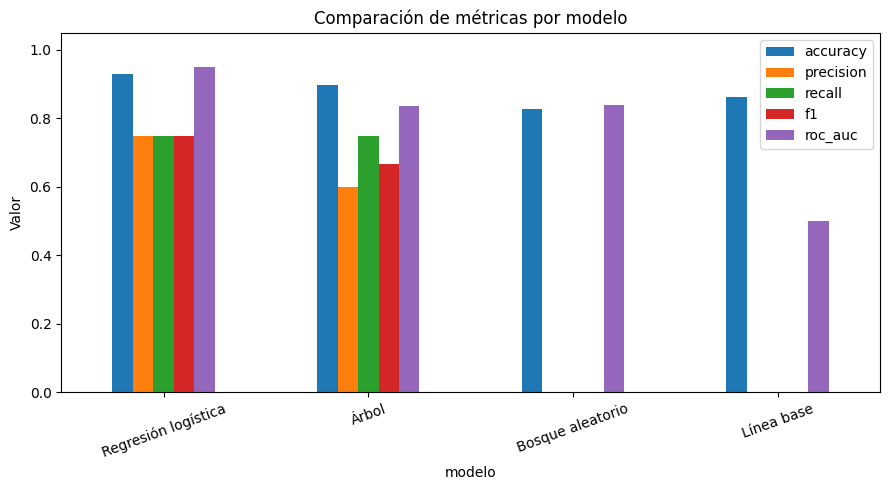

In [43]:
# Debes ejecutar este bloque

metricas = ["accuracy", "precision", "recall", "f1", "roc_auc"]
fig, ax = plt.subplots(figsize=(9, 5))

tabla_graf = tabla_resultados.set_index("modelo")[metricas]
tabla_graf.plot(kind="bar", ax=ax)
ax.set_title("Comparación de métricas por modelo")
ax.set_ylabel("Valor")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# 7. Análisis del mejor modelo

Ahora vamos a estudiar con más detalle el modelo que haya quedado mejor situado en la tabla.


In [44]:
# Debes ejecutar y revisar este bloque

mejor_modelo = tabla_resultados.iloc[0]["modelo"]
print("Mejor modelo según la tabla:", mejor_modelo)

pipe_mejor = modelos_ajustados[mejor_modelo]
y_pred_mejor = pipe_mejor.predict(X_test)

print(classification_report(y_test, y_pred_mejor, zero_division=0))


Mejor modelo según la tabla: Regresión logística
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        25
           1       0.75      0.75      0.75         4

    accuracy                           0.93        29
   macro avg       0.85      0.85      0.85        29
weighted avg       0.93      0.93      0.93        29



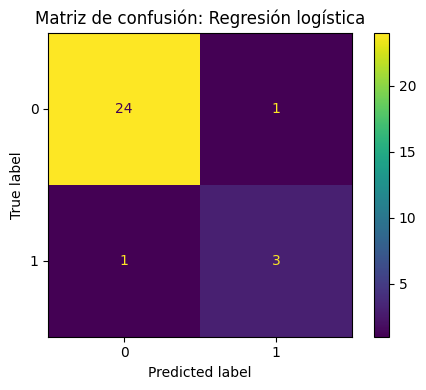

In [45]:
# Debes ejecutar este bloque

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_estimator(pipe_mejor, X_test, y_test, ax=ax)
plt.title(f"Matriz de confusión: {mejor_modelo}")
plt.tight_layout()
plt.show()


## Debes interpretar

Explica qué significa la matriz de confusión de tu mejor clasificador.

Debes comentar al menos:

- verdaderos positivos,
- verdaderos negativos,
- falsos positivos,
- falsos negativos,
- y qué tipo de error parece más frecuente.


> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

De 25 personas que no tienen sospecha de covid, el modelo acierta 24 y falla en 1 (falso positivo). De las 4 que si tienen sospecha de covid, acierta 3 y falla en 1 (falso negativo). Analizando la matriz de confusión vemos que el modelo falla, aunque sea poco, un 25% de las veces en sospecha de covid.

<Figure size 700x600 with 0 Axes>

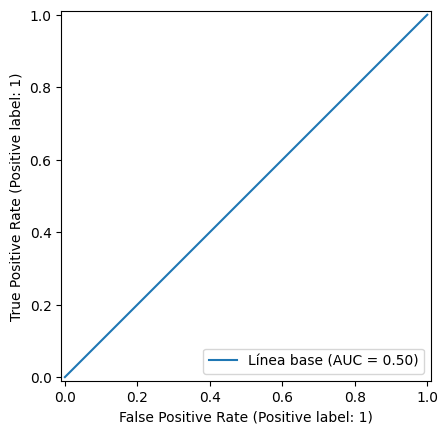

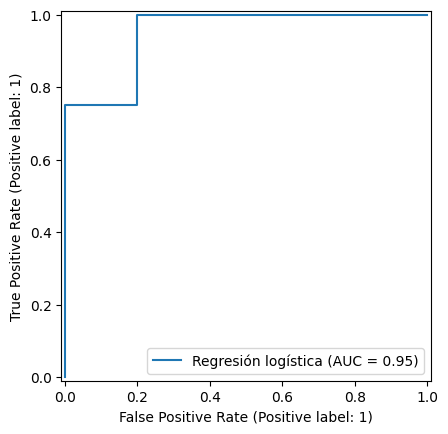

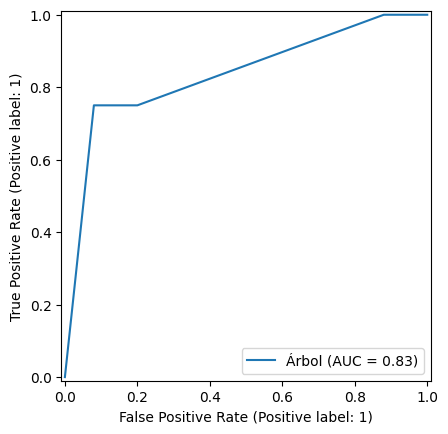

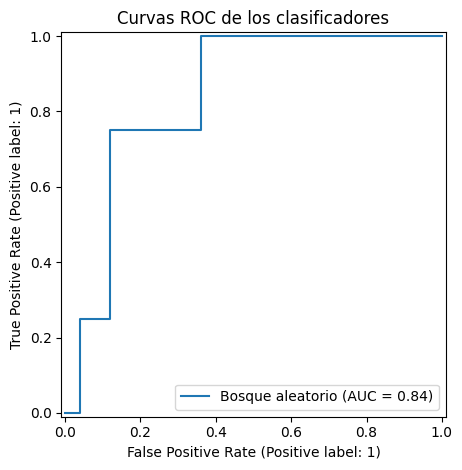

In [46]:
# Debes ejecutar este bloque

plt.figure(figsize=(7, 6))

for nombre, pipe in modelos_ajustados.items():
    if hasattr(pipe, "predict_proba"):
        RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=nombre)

plt.title("Curvas ROC de los clasificadores")
plt.tight_layout()
plt.show()


## Debes interpretar

Explica:

- qué representa una curva ROC,
- qué significa un AUC alto,
- y qué modelo parece separar mejor las clases.


> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

La curva ROC grafica la tasa de verdaderos positivos vs falsos positivos. Lo ideal es que la gráfica pase por (0, 1). AUC es un valor entre 0 y 1 que mide el area bajo la curva de ROC. Lo ideal es obtener un AUC cercano a 1. Un valor menor que 0.5 indica un modelo peor que el azar. Analizando los valores de AUC, la regresión logística es la que da mejores resultados.

,variable,importancia
9,num__sintomas_n,0.279994
0,num__edad,0.220608
7,num__enf_respiratorias_n,0.155302
1,num__imc,0.129174
6,num__enf_metabolicas_n,0.059785
10,num__contacto_covid_bin,0.040233
12,cat__sexo_1,0.027810
11,cat__sexo_0,0.025337
5,num__tranquilizantes_bin,0.022044
8,num__epoc_riesgo_bin,0.020969


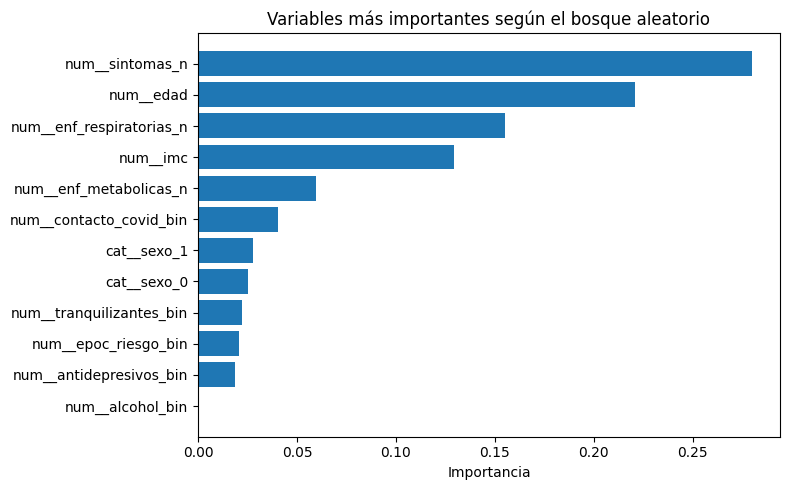

In [47]:
# Debes ejecutar este bloque

pipe_bosque = modelos_ajustados["Bosque aleatorio"]

nombres_transformados = pipe_bosque.named_steps["prep"].get_feature_names_out()
importancias = pipe_bosque.named_steps["clf"].feature_importances_

tabla_importancias = (
    pd.DataFrame({"variable": nombres_transformados, "importancia": importancias})
    .sort_values("importancia", ascending=False)
    .head(12)
)

display(tabla_importancias)

plt.figure(figsize=(8, 5))
plt.barh(tabla_importancias["variable"][::-1], tabla_importancias["importancia"][::-1])
plt.title("Variables más importantes según el bosque aleatorio")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


## Debes interpretar

Comenta cuáles son las variables más influyentes según el bosque aleatorio.

No digas solo la lista: intenta explicar por qué esas variables podrían ayudar a clasificar la sospecha de COVID.


> **Respuesta del estudiante:**  
> Escribe aquí tu respuesta.

Vemos que los síntomas influyen en si una persona realmente tiene sospecha de covid o no. Esto tiene sentido ya que es lo primero que se analiza en un paciente. En segundo lugar tenemos la edad. Esta variable es interesante. A lo mejor la edad nos ayuda ya que personas más mayores son más propensos a tener síntomas o problemas de salud, por lo que para el modelo infuye mucho. Seguimos con el número de enfermedades respiratorias que tiene una persona. Como el covid tiene síntomas relacionados con la respiración, es una buena variable con la que relacionar.

# 8. Actividad opcional de ampliación

Si terminas antes o quieres profundizar más, elige **una sola** de estas ampliaciones:

1. Cambia `max_depth` del árbol y comenta cómo varían las métricas.
2. Cambia `n_estimators` o `max_depth` del bosque aleatorio y compara el resultado.
3. Prueba una selección distinta de variables predictoras y comenta si mejora o empeora la clasificación.

> Esta parte es opcional y no hace falta hacerla para completar la versión reducida de la práctica.


In [48]:
# Debes completar esta parte solo si realizas la ampliación

# Escribe aquí tu prueba opcional.
# Ejemplo orientativo:
# modelos["Árbol profundo"] = DecisionTreeClassifier(max_depth=8, random_state=42)


# 9. Preguntas finales obligatorias

Responde con frases completas.

1. ¿Qué variable objetivo has usado y cómo la has recodificado?
2. ¿Qué variables predictoras has utilizado finalmente?
3. ¿Qué modelo ha funcionado mejor y con qué métrica lo justificas?
4. ¿Qué te dice la matriz de confusión sobre los errores del modelo?
5. ¿Qué variables parecen más relevantes según el bosque aleatorio?
6. ¿Por qué no debe interpretarse este estudio como causal?
7. ¿Qué limitaciones tiene trabajar con una muestra reducida y con datos de encuesta?


> **Respuesta final del estudiante:**  
> Escribe aquí tu respuesta.

1. He usado la columna de covid sospecha ya que es la mejor variable que nos puede indicar si alguien puede realmente tener covid. Para recodificarlo, he cambiado los valores "si" por 1 y todo lo demás a 0, ya que es mejor poner un 0 que inventarnos que alguien tiene sospecha de covid.
2. He usado las variables que indica la práctica: "sexo", "edad", "imc", "fumador_bin", "alcohol_bin", "antidepresivos_bin", "tranquilizantes_bin", "enf_metabolicas_n", "enf_respiratorias_n", "epoc_riesgo_bin", "sintomas_n", "contacto_covid_bin".
3. La regresión logística, por un alto accuracy y reforzado por un alto f1. Además tiene el mayor valor de AUC.
4. Falla un 25% para gente que si tiene sospechas (falso negativo) y tiene un muy bajo porcentaje de falsos positivios.
5. El número de síntomas, la edad y el numéro de enfermedades respiratorias.
6. Los resultados indican que hay ciertas variables que suelen estar relacionadas con la sospecha de covid, pero esto no significa que exista una relación directa entre ellas.
7. Son muy pocos datos para realizar informes con resultados buenos y robustos. Tener pocos datos introduce sesgo y más cuando la relacion entre la variable objetivo esta muy desbalanceada. Añadiendo además que es una encuesta, se introduce más sesgo, datos anómalos por subjetividad de las personas encuestadas. A pesar de ello este análisis sirve para ver tendencias y generar hipótesis para análisis más en condiciones.

# 10. Cierre

Si has llegado hasta aquí, has realizado una práctica completa y compacta de **clasificación supervisada** usando datos reales de una encuesta sobre COVID.

Has trabajado con:

- preparación de variables,
- partición entrenamiento/prueba,
- varios clasificadores clásicos,
- métricas de evaluación,
- matriz de confusión,
- curvas ROC,
- e importancia de variables.

Ese es un flujo de trabajo muy típico en aprendizaje computacional aplicado.
